<a href="https://colab.research.google.com/github/maverick8675309/seaid-framework/blob/main/Notebooks/09_Model_Comparison_and_Interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [2]:
!ls -la /content

total 16
drwxr-xr-x 1 root root 4096 Jun  4 13:39 .
drwxr-xr-x 1 root root 4096 Aug  6 19:25 ..
drwxr-xr-x 4 root root 4096 Jun  4 13:39 .config
drwxr-xr-x 1 root root 4096 Jun  4 13:39 sample_data


In [3]:
!rm -rf /content/drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/SEAID_Framework")

print("Project exists:", PROJECT_DIR.exists())
print("Project contents:")

for item in sorted(PROJECT_DIR.iterdir()):
    print("-", item.name)

Project exists: True
Project contents:
- data
- figures
- models
- models_portable
- notebooks
- outputs
- results


In [6]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/SEAID_Framework")

PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

# Model Comparison and Interpretation

This notebook compares five SEAID temporal early-warning models across Days 7, 14, 21, and 30:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- Neural Network

The code below loads the temporal results generated by Notebooks 04–08 from their actual saved locations, standardizes their columns, combines them into one comparison table, and saves the consolidated results.


In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path("/content/drive/MyDrive/SEAID_Framework")

PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)
print("Outputs directory:", OUTPUTS_DIR)
print("Results directory:", RESULTS_DIR)


Project directory: /content/drive/MyDrive/SEAID_Framework
Processed data directory: /content/drive/MyDrive/SEAID_Framework/data/processed
Outputs directory: /content/drive/MyDrive/SEAID_Framework/outputs
Results directory: /content/drive/MyDrive/SEAID_Framework/results


In [8]:
# Actual temporal-result files produced by Notebooks 04-08

TEMPORAL_RESULT_FILES = {
    "Logistic Regression": (
        PROCESSED_DATA_DIR /
        "logistic_regression_temporal_results.csv"
    ),
    "Decision Tree": (
        PROCESSED_DATA_DIR /
        "decision_tree_temporal_results.csv"
    ),
    "Random Forest": (
        OUTPUTS_DIR /
        "random_forest_temporal_results.csv"
    ),
    "XGBoost": (
        OUTPUTS_DIR /
        "xgboost_temporal_results.csv"
    ),
    "Neural Network": (
        RESULTS_DIR /
        "neural_network_temporal_model_comparison.csv"
    )
}

for model_name, file_path in TEMPORAL_RESULT_FILES.items():
    print(
        f"{model_name}: "
        f"{'FOUND' if file_path.exists() else 'MISSING'} "
        f"- {file_path}"
    )


Logistic Regression: FOUND - /content/drive/MyDrive/SEAID_Framework/data/processed/logistic_regression_temporal_results.csv
Decision Tree: FOUND - /content/drive/MyDrive/SEAID_Framework/data/processed/decision_tree_temporal_results.csv
Random Forest: FOUND - /content/drive/MyDrive/SEAID_Framework/outputs/random_forest_temporal_results.csv
XGBoost: FOUND - /content/drive/MyDrive/SEAID_Framework/outputs/xgboost_temporal_results.csv
Neural Network: FOUND - /content/drive/MyDrive/SEAID_Framework/results/neural_network_temporal_model_comparison.csv


In [9]:
def standardize_temporal_results(
    model_name,
    file_path
):
    """Load one model's temporal results and standardize its schema."""

    if not file_path.exists():
        print(
            f"Skipping {model_name}: file not found - "
            f"{file_path.name}"
        )
        return None

    model_df = pd.read_csv(file_path)

    rename_map = {
        "Day": "Checkpoint Day",
        "Checkpoint": "Checkpoint Day",
        "checkpoint_day": "Checkpoint Day",
        "F1": "F1 Score",
        "ROC_AUC": "ROC-AUC",
        "ROC AUC": "ROC-AUC",
        "PR_AUC": "PR-AUC",
        "PR AUC": "PR-AUC"
    }

    model_df = model_df.rename(
        columns=rename_map
    )

    # Ensure the correct model name is present.
    model_df["Model"] = model_name

    required_columns = [
        "Checkpoint Day",
        "Accuracy",
        "Precision - Successful",
        "Recall - Successful",
        "Recall - Unsuccessful",
        "F1 Score",
        "ROC-AUC",
        "At-Risk Students Missed",
        "Successful Students Flagged"
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in model_df.columns
    ]

    if missing_columns:
        print(
            f"Skipping {model_name}: missing columns "
            f"{missing_columns}"
        )
        print(
            "Available columns:",
            model_df.columns.tolist()
        )
        return None

    optional_columns = [
        "Students",
        "Features",
        "Training Epochs",
        "PR-AUC"
    ]

    selected_columns = (
        ["Model"]
        + [
            column
            for column in optional_columns
            if column in model_df.columns
        ]
        + required_columns
    )

    model_df = model_df[selected_columns].copy()

    numeric_columns = [
        column
        for column in model_df.columns
        if column != "Model"
    ]

    for column in numeric_columns:
        model_df[column] = pd.to_numeric(
            model_df[column],
            errors="coerce"
        )

    model_df = model_df.dropna(
        subset=[
            "Checkpoint Day",
            "ROC-AUC"
        ]
    )

    model_df["Checkpoint Day"] = (
        model_df["Checkpoint Day"].astype(int)
    )

    return model_df


In [10]:
temporal_frames = []

for model_name, file_path in TEMPORAL_RESULT_FILES.items():

    standardized_df = standardize_temporal_results(
        model_name=model_name,
        file_path=file_path
    )

    if standardized_df is not None:
        temporal_frames.append(
            standardized_df
        )

if not temporal_frames:
    raise FileNotFoundError(
        "No temporal model result files were loaded. "
        "Run Notebooks 04-08 first."
    )

all_models_results_df = pd.concat(
    temporal_frames,
    ignore_index=True,
    sort=False
)

all_models_results_df = (
    all_models_results_df
    .sort_values(
        [
            "Checkpoint Day",
            "Model"
        ]
    )
    .reset_index(drop=True)
)

print("\nRows by model:")
print(
    all_models_results_df
    .groupby("Model")
    .size()
)

print(
    "\nTotal rows:",
    len(all_models_results_df)
)

display(all_models_results_df)



Rows by model:
Model
Decision Tree          4
Logistic Regression    4
Neural Network         4
Random Forest          4
XGBoost                4
dtype: int64

Total rows: 20


,Model,Students,Features,Checkpoint Day,Accuracy,Precision - Successful,Recall - Successful,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged,Training Epochs,PR-AUC
0,Decision Tree,32593,72.0,7,0.6791,0.6477,0.7020,0.6586,0.6737,0.7424,1175,917,NaN,NaN
1,Logistic Regression,32593,72.0,7,0.6970,0.6697,0.7065,0.6886,0.6876,0.7698,1072,903,NaN,NaN
2,Neural Network,32593,72.0,7,0.6970,0.6549,0.7569,0.6435,0.7022,0.7706,1227,748,24.0,0.7246
3,Random Forest,32593,NaN,7,0.7055,0.6772,0.7186,0.6938,0.6973,0.7778,1054,866,NaN,NaN
4,XGBoost,32593,NaN,7,0.7171,0.6907,0.7257,0.7095,0.7078,0.7904,1000,844,NaN,NaN
5,Decision Tree,32593,72.0,14,0.6897,0.6678,0.6815,0.6970,0.6746,0.7589,1043,980,NaN,NaN
6,Logistic Regression,32593,72.0,14,0.7090,0.6789,0.7277,0.6923,0.7024,0.7844,1059,838,NaN,NaN
7,Neural Network,32593,72.0,14,0.7062,0.6588,0.7832,0.6374,0.7157,0.7879,1248,667,23.0,0.7385
8,Random Forest,32593,NaN,14,0.7173,0.6863,0.7387,0.6981,0.7115,0.7934,1039,804,NaN,NaN
9,XGBoost,32593,NaN,14,0.7222,0.6907,0.7452,0.7016,0.7169,0.8032,1027,784,NaN,NaN


In [11]:
# Confirm that each available model has all four checkpoints.

expected_checkpoints = {
    7,
    14,
    21,
    30
}

checkpoint_validation = (
    all_models_results_df
    .groupby("Model")["Checkpoint Day"]
    .apply(
        lambda values: sorted(
            values.astype(int).unique().tolist()
        )
    )
)

display(
    checkpoint_validation.to_frame(
        name="Available Checkpoints"
    )
)

for model_name, checkpoints in checkpoint_validation.items():

    missing_checkpoints = sorted(
        expected_checkpoints
        - set(checkpoints)
    )

    if missing_checkpoints:
        print(
            f"Warning: {model_name} is missing "
            f"checkpoints {missing_checkpoints}"
        )


,Available Checkpoints
Model,
Decision Tree,"[7, 14, 21, 30]"
Logistic Regression,"[7, 14, 21, 30]"
Neural Network,"[7, 14, 21, 30]"
Random Forest,"[7, 14, 21, 30]"
XGBoost,"[7, 14, 21, 30]"


In [12]:
COMPARISON_PATH = (
    RESULTS_DIR /
    "all_models_temporal_comparison.csv"
)

all_models_results_df.to_csv(
    COMPARISON_PATH,
    index=False
)

print("Saved consolidated comparison:")
print(COMPARISON_PATH)


Saved consolidated comparison:
/content/drive/MyDrive/SEAID_Framework/results/all_models_temporal_comparison.csv


In [13]:
best_by_checkpoint = (
    all_models_results_df
    .sort_values(
        ["Checkpoint Day", "ROC-AUC"],
        ascending=[True, False]
    )
    .groupby(
        "Checkpoint Day",
        as_index=False
    )
    .first()
)

best_by_checkpoint = best_by_checkpoint[
    [
        "Checkpoint Day",
        "Model",
        "Accuracy",
        "Recall - Unsuccessful",
        "F1 Score",
        "ROC-AUC",
        "At-Risk Students Missed",
        "Successful Students Flagged"
    ]
]

display(best_by_checkpoint)


,Checkpoint Day,Model,Accuracy,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged
0,7,XGBoost,0.7171,0.7095,0.7078,0.7904,1000,844
1,14,XGBoost,0.7222,0.7016,0.7169,0.8032,1027,784
2,21,XGBoost,0.7567,0.7211,0.7555,0.8388,960,626
3,30,XGBoost,0.7757,0.7295,0.7769,0.8568,931,531


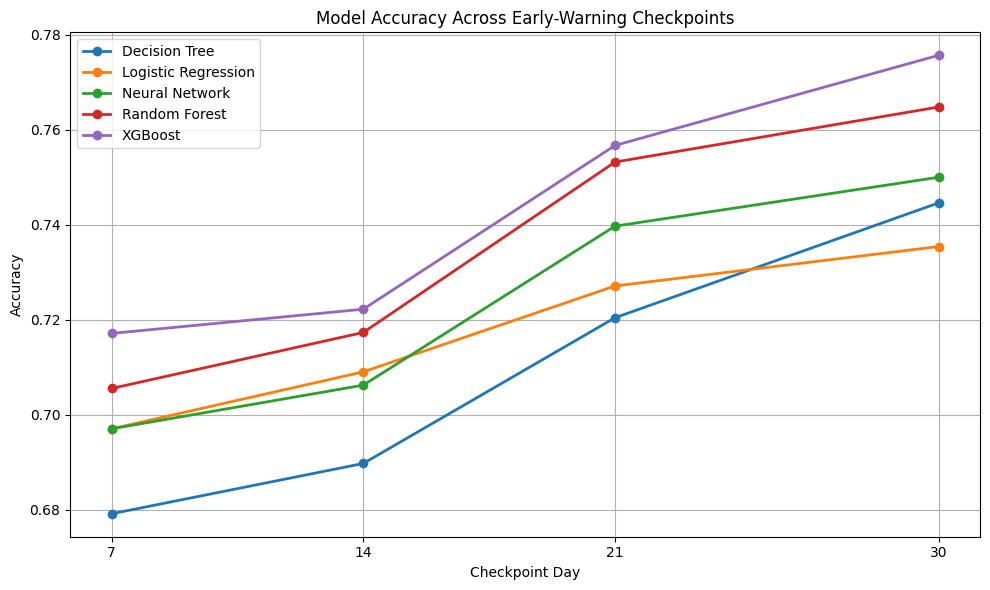

In [14]:
plt.figure(figsize=(10,6))

for model in all_models_results_df["Model"].unique():

    subset = all_models_results_df[
        all_models_results_df["Model"] == model
    ]

    plt.plot(
        subset["Checkpoint Day"],
        subset["Accuracy"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("Model Accuracy Across Early-Warning Checkpoints")

plt.xlabel("Checkpoint Day")
plt.ylabel("Accuracy")

plt.xticks([7,14,21,30])

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "accuracy_comparison.png",
    dpi=300
)

plt.show()

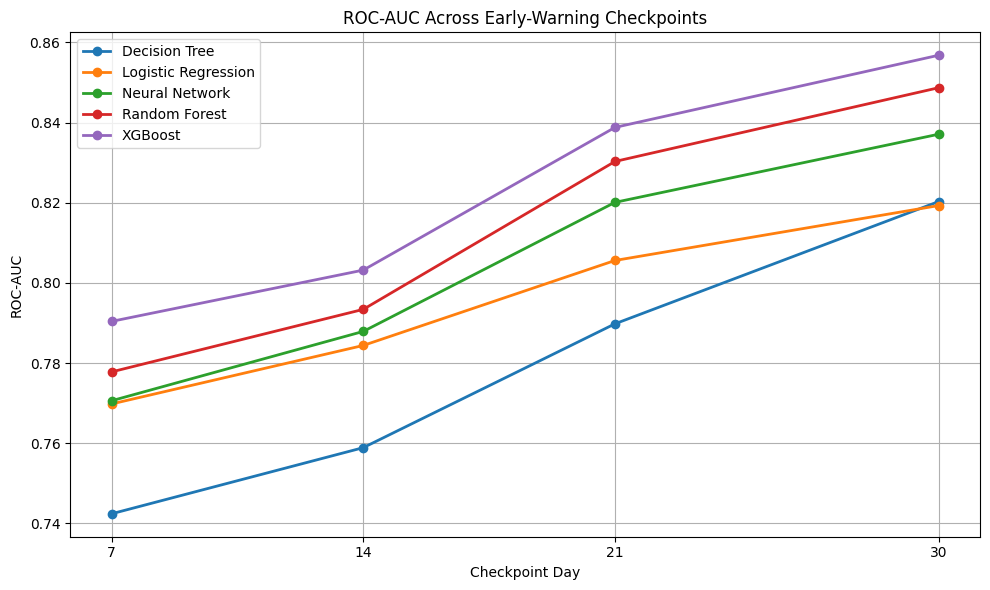

In [15]:
plt.figure(figsize=(10,6))

for model in all_models_results_df["Model"].unique():

    subset = all_models_results_df[
        all_models_results_df["Model"] == model
    ]

    plt.plot(
        subset["Checkpoint Day"],
        subset["ROC-AUC"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("ROC-AUC Across Early-Warning Checkpoints")

plt.xlabel("Checkpoint Day")
plt.ylabel("ROC-AUC")

plt.xticks([7,14,21,30])

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "roc_auc_comparison.png",
    dpi=300
)

plt.show()

## Precision-Recall AUC

PR-AUC is included when a model notebook saved that metric. Because earlier traditional-model notebooks may not report PR-AUC, this chart uses only models with available values.


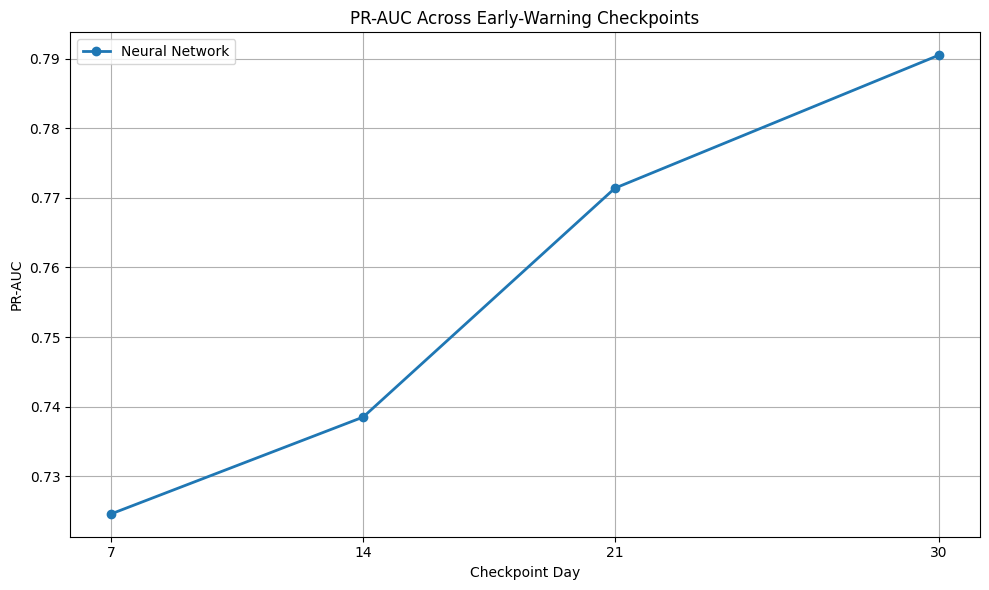

In [16]:
if (
    "PR-AUC" in all_models_results_df.columns
    and all_models_results_df["PR-AUC"].notna().any()
):
    plt.figure(figsize=(10, 6))

    pr_auc_data = all_models_results_df.dropna(
        subset=["PR-AUC"]
    )

    for model in pr_auc_data["Model"].unique():

        subset = (
            pr_auc_data[
                pr_auc_data["Model"] == model
            ]
            .sort_values("Checkpoint Day")
        )

        plt.plot(
            subset["Checkpoint Day"],
            subset["PR-AUC"],
            marker="o",
            linewidth=2,
            label=model
        )

    plt.title(
        "PR-AUC Across Early-Warning Checkpoints"
    )
    plt.xlabel("Checkpoint Day")
    plt.ylabel("PR-AUC")
    plt.xticks([7, 14, 21, 30])
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR /
        "pr_auc_comparison.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
else:
    print(
        "PR-AUC was not available for the loaded models."
    )


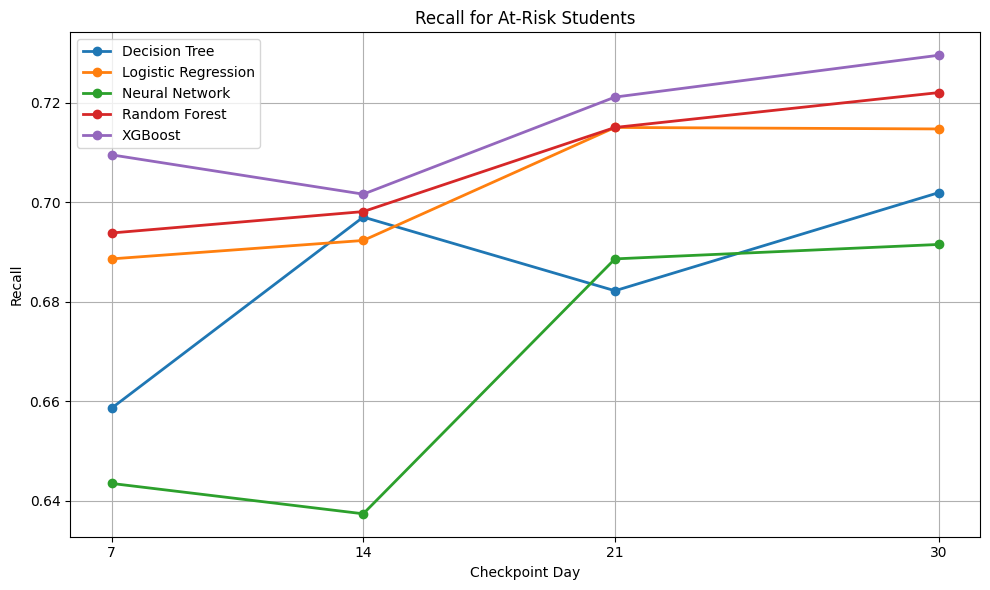

In [17]:
plt.figure(figsize=(10,6))

for model in all_models_results_df["Model"].unique():

    subset = all_models_results_df[
        all_models_results_df["Model"] == model
    ]

    plt.plot(
        subset["Checkpoint Day"],
        subset["Recall - Unsuccessful"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("Recall for At-Risk Students")

plt.xlabel("Checkpoint Day")
plt.ylabel("Recall")

plt.xticks([7,14,21,30])

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "recall_unsuccessful_comparison.png",
    dpi=300
)

plt.show()

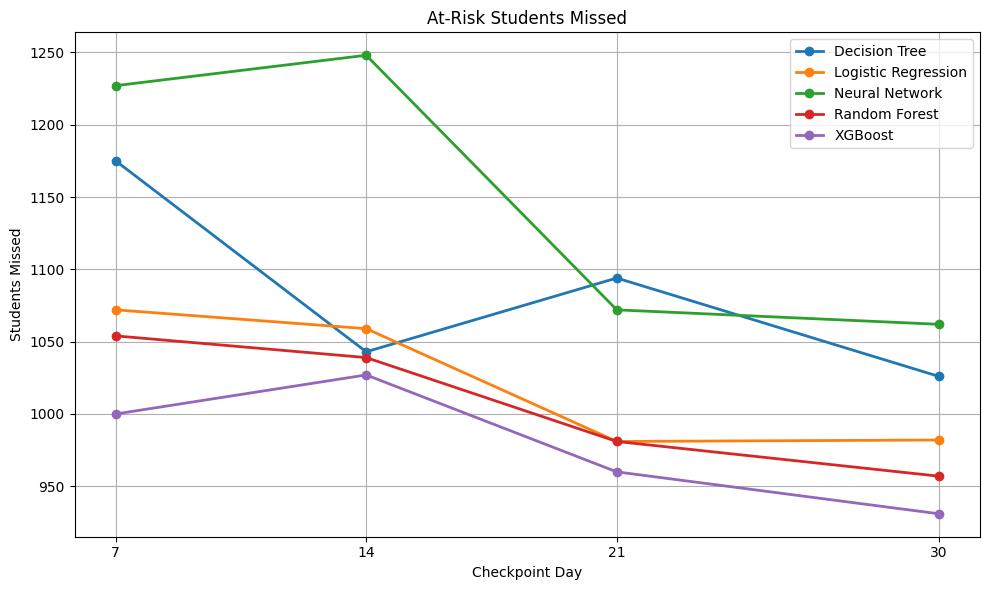

In [18]:
plt.figure(figsize=(10,6))

for model in all_models_results_df["Model"].unique():

    subset = all_models_results_df[
        all_models_results_df["Model"] == model
    ]

    plt.plot(
        subset["Checkpoint Day"],
        subset["At-Risk Students Missed"],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("At-Risk Students Missed")

plt.xlabel("Checkpoint Day")
plt.ylabel("Students Missed")

plt.xticks([7,14,21,30])

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "at_risk_students_missed.png",
    dpi=300
)

plt.show()

In [19]:
import os

print(sorted(os.listdir(FIGURES_DIR)))

['accuracy_comparison.png', 'at_risk_students_missed.png', 'average_risk_over_time.png', 'day30_calibration_curve.png', 'decision_tree_confusion_matrix.png', 'decision_tree_feature_importance.png', 'decision_tree_roc_curve.png', 'decision_tree_temporal_performance.png', 'exploration', 'highest_risk_student_waterfall.png', 'logistic_regression_confusion_matrix.png', 'logistic_regression_roc_curve.png', 'logistic_regression_temporal_performance.png', 'neural_network_day30_auc_curve.png', 'neural_network_day30_confusion_matrix.png', 'neural_network_day30_loss_curve.png', 'neural_network_day30_precision_recall_curve.png', 'neural_network_day30_probability_distribution.png', 'neural_network_day30_roc_curve.png', 'neural_network_temporal_performance.png', 'neural_network_temporal_roc_auc_at_risk_recall.png', 'pr_auc_comparison.png', 'random_forest_confusion_matrix.png', 'random_forest_day30_temporal_feature_importance.png', 'random_forest_feature_importance.png', 'random_forest_roc_curve.png

In [20]:
BEST_MODEL_PATH = (
    RESULTS_DIR
    / "best_model_by_checkpoint.csv"
)

best_by_checkpoint.to_csv(
    BEST_MODEL_PATH,
    index=False
)

print("Saved:")
print(BEST_MODEL_PATH)

Saved:
/content/drive/MyDrive/SEAID_Framework/results/best_model_by_checkpoint.csv


In [21]:
overall_model_summary = (
    all_models_results_df
    .groupby("Model", as_index=False)
    .agg(
        Mean_Accuracy=("Accuracy", "mean"),
        Mean_ROC_AUC=("ROC-AUC", "mean"),
        Mean_Recall_Unsuccessful=(
            "Recall - Unsuccessful",
            "mean"
        ),
        Mean_F1=("F1 Score", "mean"),
        Mean_At_Risk_Missed=(
            "At-Risk Students Missed",
            "mean"
        ),
        Mean_Successful_Flagged=(
            "Successful Students Flagged",
            "mean"
        )
    )
)

In [22]:
overall_model_summary = (
    overall_model_summary
    .sort_values(
        "Mean_ROC_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

overall_model_summary.insert(
    0,
    "Overall Rank",
    range(
        1,
        len(overall_model_summary) + 1
    )
)

display(overall_model_summary)

,Overall Rank,Model,Mean_Accuracy,Mean_ROC_AUC,Mean_Recall_Unsuccessful,Mean_F1,Mean_At_Risk_Missed,Mean_Successful_Flagged
0,1,XGBoost,0.742925,0.822300,0.715425,0.739275,979.50,696.25
1,2,Random Forest,0.735200,0.812550,0.707225,0.731725,1007.75,718.50
2,3,Neural Network,0.723225,0.803925,0.665250,0.728900,1152.25,652.00
3,4,Logistic Regression,0.717125,0.794775,0.702650,0.709875,1023.50,820.50
4,5,Decision Tree,0.708450,0.777850,0.684925,0.703550,1084.50,816.25


In [23]:
OVERALL_SUMMARY_PATH = (
    RESULTS_DIR
    / "overall_model_summary.csv"
)

overall_model_summary.to_csv(
    OVERALL_SUMMARY_PATH,
    index=False
)

print("Saved:")
print(OVERALL_SUMMARY_PATH)

Saved:
/content/drive/MyDrive/SEAID_Framework/results/overall_model_summary.csv


## Model Comparison and Interpretation

The temporal comparison evaluates five classification models at Days 7, 14, 21, and 30:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- Neural Network

The comparison should be interpreted across multiple dimensions. ROC-AUC measures overall discrimination, while recall for unsuccessful students indicates how effectively the model identifies students who may need intervention. Accuracy and F1 provide additional balance measures, and the operational counts show how many at-risk students are missed or how many successful students may receive unnecessary outreach.

The tables and figures generated above should be treated as the source of truth for the final recommendation. The strongest institutional model is not automatically the model with the highest single metric; SEAID also considers early usefulness, interpretability, computational complexity, and the consequences of missed students.


## Operational Implications

The results support a staged intervention strategy rather than relying on a single prediction date.

- **Day 7:** Use predictions for broad, low-cost outreach and early check-ins.
- **Day 14:** Prioritize students showing continued disengagement or elevated risk.
- **Day 21:** Begin more targeted advising, academic support, and instructor intervention.
- **Day 30:** Use the strongest available predictions for intensive retention support.

Although Day 30 produced the best predictive performance, waiting until Day 30 would reduce the amount of time available for meaningful intervention. The Day 7 and Day 14 models therefore remain valuable even though their performance is lower.

The practical value of the framework lies in balancing prediction quality with intervention timing. Earlier predictions provide more time to act, while later predictions provide greater confidence.

## Final Model Recommendation

The primary SEAID model should be selected using the consolidated results generated in this notebook.

The recommendation should consider:

1. Mean ROC-AUC across all temporal checkpoints.
2. Performance at the earliest actionable checkpoints.
3. Recall for unsuccessful students.
4. The number of at-risk students missed.
5. The number of successful students unnecessarily flagged.
6. Interpretability and deployment requirements.
7. Whether the neural network provides a meaningful improvement over simpler models.

The highest-ranked model in `overall_model_summary` is the leading predictive candidate. However, a simpler model may remain preferable when its performance is comparable and institutional transparency is a priority.


In [24]:
print("Results files:")

for file_path in sorted(RESULTS_DIR.iterdir()):
    print("-", file_path.name)

Results files:
- all_models_temporal_comparison.csv
- best_model_by_checkpoint.csv
- day30_model_summary.csv
- day7_to_day30_transition_matrix.csv
- intervention_dashboard.csv
- neural_network_day14_training_history.csv
- neural_network_day21_training_history.csv
- neural_network_day30_configuration.json
- neural_network_day30_metrics.csv
- neural_network_day30_threshold_analysis.csv
- neural_network_day30_training_history.csv
- neural_network_day7_training_history.csv
- neural_network_temporal_model_comparison.csv
- neural_network_temporal_results.csv
- overall_model_summary.csv
- shap_behavioral_academic_importance_day30.csv
- shap_feature_importance_day30.csv
- student_risk_predictions.csv
- student_risk_tracker.csv
- student_risk_transition_analysis.csv
